---
title: "MTG Lightning Imager Accumulated Flash Radiance (AFR)"
subtitle: "Access, exploration and visualization of MTG LI Accumulated Flash Radiance data using the Destination Earth Data Lake HDA service."
author: "Serena Avolio (EUMETSAT/Starion)"
tags: [HDA, MTG, LI, Lightning]
thumbnail: ../../img/EUMETSAT-icon.png
license: MIT
copyright: "© 2026 EUMETSAT"
---
<div style="margin: 6px 0;">
  <a href="https://jupyter.central.data.destination-earth.eu/user-redirect/lab/tree/DestinE-DataLake-Lab/HDA/EUM_data/DEDL-HDA-EO.EUM.DAT.MTG.ipynb" target="_blank" style="text-decoration: none;">
    <span class="launch">🚀 Launch in JupyterHub</span>
  </a>
</div>

### Contents
- **Objective:** This notebook has the aim to show how to request the **LI Accumulated Flash Radiance (AFR)** product (`EO:EUM:DAT:0688`), available through EUMETSAT and federated within the Destination Earth Data Lake.
- **Data Sources:** The notebook uses the **LI Accumulated Flash Radiance (AFR)** product [`EO:EUM:DAT:0688`](https://data.eumetsat.int/product/EO:EUM:DAT:0688), available through EUMETSAT and federated within the Destination Earth Data Lake.
- **Methods:** In this notebook, we demonstrate how to:
    - Authenticate to the Destination Earth Data Lake using the Harmonized Data Access (HDA) service.
    - Search for MTG Lightning Imager Accumulated Flash Radiance (AFR) products.
    - Download and extract the product structure.
    - Explore the structure of the product variables.
    - Convert the MTG geostationary coordinates into geographic latitude and longitude.
    - Visualize lightning activity using Cartopy and geospatial scatter plots.
    - Focus the analysis on a selected region over Northern Italy.
- **Prerequisites:** 
   - To search and access DEDL data a <a href="https://platform.destine.eu/"> DestinE user account</a> is needed
   - To search and access DT data an <a href="https://platform.destine.eu/support-pages/access-policy/"> upgraded access</a> is needed.
- **Expected Output:**
    - 1 AFR (Accumulated Flash Radiance) product archive  containing the requested data,
    - 1 scatter plot of the  Radiance Variable over Northern Italy on 21 July 2026. During this period, a powerful thunderstorm developed over the Po Valley and propagated towards the Adriatic Sea.

## Setup
Let's import useful packages

In [1]:
import destinelab as deauth

In [2]:
import requests
import json
import os
import zipfile
import datetime
import shutil
from getpass import getpass

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

## Authenticate

Access to the Destination Earth Data Lake requires authentication using valid DESP credentials.

The authentication step retrieves a temporary access token that is subsequently used to authorize all requests to the HDA APIs.
The token is included in the HTTP authorization header and enables secure access to metadata and data assets.

In [3]:
DESP_USERNAME = input("Please input your DESP username or email: ")
DESP_PASSWORD = getpass("Please input your DESP password: ")

auth = deauth.AuthHandler(DESP_USERNAME, DESP_PASSWORD)
access_token = auth.get_token()
if access_token is not None:
    print("DEDL/DESP Access Token Obtained Successfully")
else:
    print("Failed to Obtain DEDL/DESP Access Token")

auth_headers = {"Authorization": f"Bearer {access_token}"}

Please input your DESP username or email:  eum-dedl-user
Please input your DESP password:  ········


DEDL/DESP Access Token Obtained Successfully


##  Search for MTG Lightning Imager Products

The Harmonized Data Access (HDA) catalogue exposes datasets through a STAC-compliant interface.

In this example, we query the collection:

[`EO.EUM.DAT.MTG.LI-AFR`](https://data.destination-earth.eu/data-portfolio/EO.EUM.DAT.MTG.LI-AFR)

which corresponds to the [EUMETSAT MTG Lightning Imager Accumulated Flash Radiance (AFR) product](https://data.eumetsat.int/product/EO:EUM:DAT:0688).

The temporal search window was selected to capture the severe convective event that affected Northern Italy on **21 July 2026**. During this period, a powerful thunderstorm developed over the Po Valley and propagated towards the Adriatic Sea
The AFR observations acquired between **10:10 UTC and 10:30 UTC** provide an opportunity to investigate the lightning activity associated with this severe storm using the MTG Lightning Imager. The chosen time interval covers the mature phase of the convective system observed over Northern Italy. 

The search returns a STAC item containing:

- Product metadata
- Download links
- Product identifiers
- Temporal coverage information
- Associated NetCDF assets

### HDA endpoint
HDA API is based on the Spatio Temporal Asset Catalog specification (STAC), it is convenient define a costant with its endpoint.

In [4]:
HDA_STAC_ENDPOINT="https://hda.data.destination-earth.eu/stac/v2"

In [5]:
COLLECTION_ID = "EO.EUM.DAT.MTG.LI-AFR"

In [6]:
response = requests.post(HDA_STAC_ENDPOINT+"/search", headers=auth_headers, json={
    "collections": [COLLECTION_ID],
    "datetime": "2026-07-21T10:10:00Z/2026-07-21T10:30:00Z"
})
if(response.status_code!= 200):
    (print(response.text))
response.raise_for_status()

In [7]:
from IPython.display import JSON

product = response.json()["features"][0]
#JSON(product)
print("Display the first result metadata:")
print(json.dumps(response.json()["features"][0], indent=4))

Display the first result metadata:
{
    "type": "Feature",
    "assets": {
        "EOPMetadata.xml": {
            "href": "https://hda-download.eumetsat.data.destination-earth.eu/data/eumetsat/EO.EUM.DAT.MTG.LI-AFR/W_XX-EUMETSAT-Darmstadt%2CIMG%2BSAT%2CMTI1%2BLI-2-AFR--FD--x-x--ARC-x_C_EUMT_20260721103022_L2PF_OPE_20260721102000_20260721103000_N__O_0063_0000/EOPMetadata.xml",
            "type": "application/xml",
            "title": "EOPMetadata.xml",
            "roles": [
                "metadata"
            ],
            "eumesat_ds:type": "Link",
            "alternate": {
                "origin": {
                    "href": "https://api.eumetsat.int/data/download/1.0.0/collections/EO%3AEUM%3ADAT%3A0688/products/W_XX-EUMETSAT-Darmstadt%2CIMG%2BSAT%2CMTI1%2BLI-2-AFR--FD--x-x--ARC-x_C_EUMT_20260721103022_L2PF_OPE_20260721102000_20260721103000_N__O_0063_0000/entry?name=EOPMetadata.xml",
                    "type": "application/xml",
                    "title": "EOPMetadata

## Download the product archive

Each AFR product is distributed as a [SIP file](https://user.eumetsat.int/resources/user-guides/formats#ID-Submission-Information-Package-SIP), a collection of NetCDF files and metadata documents.

The notebook retrieves the product archive using the download link provided in the STAC response and extracts its contents locally.

Typical AFR ((Accumulated Flash Radiance)) products contain:

- Metadata files describing the product
- A BODY NetCDF file containing the main measurements
- A TRAIL NetCDF file containing additional information related to the accumulated lightning observations

In [8]:
from tqdm import tqdm
import time

from urllib.parse import unquote

workspace = 'data'
if not os.path.isdir(workspace):
    os.mkdir(workspace)

for asset in product["assets"]:
    download_url = product["assets"][asset]["href"]
    if asset != 'downloadLink':
        continue
    print(download_url)
    filename = workspace+'/'+unquote(download_url.split("/")[-2])
    print(filename)
    response = requests.get(download_url, headers=auth_headers)
    total_size = int(response.headers.get("content-length", 0))

    if os.path.exists(filename):
       print("The file exists.")
    else:
        print(f"downloading {filename}")

        with tqdm(total=total_size, unit="B", unit_scale=True) as progress_bar:
            with open(filename, 'wb') as f:
                for data in response.iter_content(1024):
                    progress_bar.update(len(data))
                    f.write(data)
    if asset == 'downloadLink':
        break;

https://hda-download.eumetsat.data.destination-earth.eu/data/eumetsat/EO.EUM.DAT.MTG.LI-AFR/W_XX-EUMETSAT-Darmstadt%2CIMG%2BSAT%2CMTI1%2BLI-2-AFR--FD--x-x--ARC-x_C_EUMT_20260721103022_L2PF_OPE_20260721102000_20260721103000_N__O_0063_0000/downloadLink
data/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+LI-2-AFR--FD--x-x--ARC-x_C_EUMT_20260721103022_L2PF_OPE_20260721102000_20260721103000_N__O_0063_0000
The file exists.


In [9]:
zf=zipfile.ZipFile(filename)
with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall(workspace)

## Explore the AFR (Accumulated Flash Radiance) Product Structure

The AFR product stores the lightning activity detected during the accumulation period.

Important variables include:

- `x` : geostationary projection x coordinate
- `y` : geostationary projection y coordinate
- `flash_radiance` : accumulated lightning radiance
- `mtg_geos_projection` : information required to reconstruct the geostationary projection

Inspecting the dataset structure helps identify the variables required for geolocation and visualization.

In [10]:
from glob import glob

body_file = glob(workspace+"/*BODY*.nc")[0]
trail_file = glob(workspace+"/*TRAIL*.nc")[0]

print("BODY :", body_file)
print("TRAIL:", trail_file)

BODY : data/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+LI-2-AFR--FD--CHK-BODY--ARC-NC4E_C_EUMT_20260721103022_L2PF_OPE_20260721102000_20260721103000_N__O_0063_0001.nc
TRAIL: data/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+LI-2-AFR--FD--CHK-TRAIL--ARC-NC4E_C_EUMT_20260721103023_L2PF_OPE_20260721102000_20260721103000_N__O_0063_0002.nc


## Inspect Available Variables

The following cells print all variables available in the dataset, together with their dimensions and metadata.

This step allows to understand:

- The physical meaning of each variable
- Units and coordinate systems
- Data dimensions
- Quality indicators and warning flags

In [11]:
ds = xr.open_dataset(body_file)

ds

<xarray.Dataset> Size: 3MB
Dimensions:                       (auxiliary_dataset: 2, accumulations: 20,
                                   pixels: 158943)
Dimensions without coordinates: auxiliary_dataset, accumulations, pixels
Data variables:
    auxiliary_dataset_identifier  (auxiliary_dataset) <U50 400B ...
    auxiliary_dataset_status      (auxiliary_dataset) int8 2B ...
    mtg_geos_projection           int32 4B ...
    accumulation_start_times      (accumulations) datetime64[ns] 160B ...
    accumulation_offsets          (accumulations) uint32 80B ...
    x                             (pixels) float64 1MB ...
    y                             (pixels) float64 1MB ...
    flash_radiance                (pixels) float32 636kB ...
    l1b_missing_warning           (accumulations) int8 20B ...
    l1b_geolocation_warning       (accumulations) int8 20B ...
    l1b_radiometric_warning       (accumulations) int8 20B ...
    average_flash_qa              (accumulations) float32 80B ...
Attributes: (12/70)
    title:                                
    summary:                              
    keywords:                             
    keywords_vocabulary:                  
    subtype:                              
    component1:                           
    ...                                   ...
    time_coverage_end:                    20260721103000
    environment:                          OPE
    type:                                 AFR
    product_id:                           LI-2-AFR-x-FD
    time_coverage_duration:               600
    disposition_mode:                     O

In [12]:
print("\nVariables:")

for var in ds.data_vars:
    print(f"\n===== {var} =====")
    print(ds[var])


Variables:

===== auxiliary_dataset_identifier =====
<xarray.DataArray 'auxiliary_dataset_identifier' (auxiliary_dataset: 2)> Size: 400B
[2 values with dtype=<U50]
Dimensions without coordinates: auxiliary_dataset
Attributes:
    long_name:  Auxiliary dataset identifier
    title:      Identifier of auxiliary dataset or type of auxiliary dataset ...

===== auxiliary_dataset_status =====
<xarray.DataArray 'auxiliary_dataset_status' (auxiliary_dataset: 2)> Size: 2B
[2 values with dtype=int8]
Dimensions without coordinates: auxiliary_dataset
Attributes:
    long_name:  Status of auxiliary dataset
    meaning:    0 = OK, 1 = out_of_validity_time, 2 = not_available

===== mtg_geos_projection =====
<xarray.DataArray 'mtg_geos_projection' ()> Size: 4B
[1 values with dtype=int32]
Attributes:
    long_name:                       MTG geostationary projection
    grid_mapping_name:               geostationary
    perspective_point_height:        35786400.0
    semi_major_axis:                 63

### Identify the Radiance Variable

The AFR product contains the variable `flash_radiance`, which represents the accumulated optical radiance associated with lightning flashes detected by the Lightning Imager.

This variable is the primary quantity used throughout the remainder of the notebook for visualization and analysis.

In [13]:
rad_var_name=''
for var in ds.data_vars:
    if "radiance" in var.lower() or "afr" in var.lower():
        print(var)
        rad_var_name=var

flash_radiance


In [14]:
afr = ds[rad_var_name]   

### Basic statistic

In [15]:
print(f"Min:  {float(afr.min())}")
print(f"Max:  {float(afr.max())}")
print(f"Mean: {float(afr.mean())}")

Min:  1.0
Max:  7170.0
Mean: 101.3907470703125


## Geolocate Lightning Observations

The Lightning Imager measurements are stored in MTG geostationary projection coordinates.

To visualize the data on a geographic map, the projection coordinates (`x`, `y`) must be transformed into latitude and longitude using the geostationary projection parameters embedded in the product metadata.

After the transformation, each lightning observation can be represented as a georeferenced point and combined with other geospatial datasets.

The functions used below are adapted from the EUMETSAT [*MTG LI Data Access*](https://gitlab.eumetsat.int/eumetlab/data-services/eumdac_data_store/-/blob/master/1_6_MTG_LI_data_access.ipynb) notebook and have been modified for the purposes of this demonstration.

In [16]:
def calculate_lat_lon(x, y):
    import warnings
    import numpy as np

    h = 42164.537
    r_eq = 6378.137
    r_p = 6356.752314

    """
    Calculate geodetic latitude and longitude in degrees from geostationary x, y coordinates.

    Args:
        x: Geostationary x-coordinate (radians).
        y: Geostationary y-coordinate (radians).

    Returns:
        Tuple (latitude, longitude) in degrees, or NaN if invalid.
    """
    try:
        s_4 = pow(r_eq, 2) / pow(r_p, 2)
        s_5 = pow(h, 2) - pow(r_eq, 2)

        # Suppress "invalid value encountered in sqrt" warnings
        with np.errstate(invalid='ignore'):
            s_d = np.sqrt(
                (h * np.cos(x) * np.cos(y))**2 - 
                (np.cos(y) ** 2 + s_4 * np.sin(y) ** 2) * s_5
            )

        sn = (h * np.cos(x) * np.cos(y) - s_d) / \
             (np.cos(y) ** 2 + s_4 * np.sin(y) ** 2)
        s1 = h - sn * np.cos(x) * np.cos(y)
        s2 = -sn * np.sin(x) * np.cos(y)
        s3 = sn * np.sin(y)
        lat = np.degrees(np.arctan(s_4 * s3 / np.sqrt(s1 ** 2 + s2 ** 2)))
        lon = np.degrees(np.arctan(s2 / s1))
        return lat, lon
    except ValueError:
        return np.nan, np.nan


In [17]:
def safe_vectorized_calculate_lat_lon(x, y):
    lat_lon = np.vectorize(calculate_lat_lon)
    try:
        return lat_lon(x, y)
    except Exception as e:
        print(f"Error in lat/lon calculation: {e}")
        return np.full(x.shape, np.nan), np.full(y.shape, np.nan)

In [18]:
x = ds['x'][:]
y = ds['y'][:]

In [19]:
latitudes, longitudes = safe_vectorized_calculate_lat_lon(x, y)

### Create a Geospatial DataFrame

The converted coordinates and radiance values are stored in a Pandas DataFrame.

This tabular representation simplifies:

- Data filtering
- Statistical analysis
- Regional subsetting
- Cartographic visualization

Each row corresponds to a geolocated lightning observation.

In [20]:

# create DataFrames
afr_radiance_df = pd.DataFrame({
    'x': x, 'y': y, 'latitude': latitudes, 'longitude': longitudes, 'flash_radiance': ds[rad_var_name][:]
}).dropna()

In [21]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_lat_lon_scatter_coastlines(
    dataframe,
    title,
    x_col='longitude',
    y_col='latitude',
    color_col=None,
    color_label=None,
    log_scale=False,
    exclude_outliers=True,
    cmap='viridis',
    extent=None  # [lon_min, lon_max, lat_min, lat_max]
):
    """
    Scatter plot with coastlines using Cartopy.

    Args:
        dataframe: Pandas DataFrame containing data to plot.
        title: Title of the plot.
        x_col: Column name for x-axis values (default: 'longitude').
        y_col: Column name for y-axis values (default: 'latitude').
        color_col: Column name for color-coding the points.
        color_label: Label for colorbar (optional).
        log_scale: Whether to apply log scale to the color data.
        exclude_outliers: Whether to exclude extreme outliers.
        cmap: Colormap to use for scatter plot.
        extent: Map extent as [lon_min, lon_max, lat_min, lat_max].
    """
    
    if color_col and color_col in dataframe.columns:
        data = dataframe[color_col]

        # Exclude outliers based on percentiles
        if exclude_outliers:
            lower_bound = data.quantile(0.01)
            upper_bound = data.quantile(0.99)
            dataframe = dataframe[
                (data >= lower_bound) & (data <= upper_bound)
            ]

        # Apply log scale if required
        color_data = (
            np.log1p(dataframe[color_col])
            if log_scale
            else dataframe[color_col]
        )
    else:
        color_data = None

    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_title(title)

    scatter = ax.scatter(
        dataframe[x_col],
        dataframe[y_col],
        c=color_data,
        cmap=cmap,
        alpha=0.7,
        transform=ccrs.PlateCarree()
    )

    # Add color bar if color_col is provided
    if color_col:
        cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', pad=0.02)
        cbar.set_label(color_label or color_col)

    # Set map extent
    if extent is not None:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    else:
        ax.set_global()

    # Add coastlines and gridlines
    ax.add_feature(cfeature.COASTLINE, edgecolor='black')
    ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        color='gray',
        alpha=0.5,
        linestyle='--'
    )

    plt.show()

## Lightning Activity over Northern Italy

To better investigate the spatial distribution of lightning activity, the visualization is restricted to Northern Italy.

The map displays geolocated lightning observations coloured according to the accumulated flash radiance.

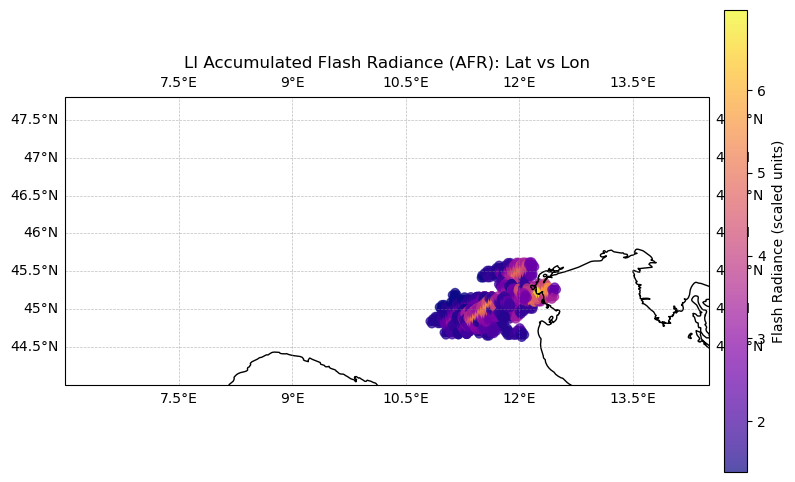

In [22]:
# Plot LI Accumulated Flash Radiance (AFR)
plot_lat_lon_scatter_coastlines(
    afr_radiance_df, 
    title="LI Accumulated Flash Radiance (AFR): Lat vs Lon",
    x_col="longitude",
    y_col="latitude",
    color_col="flash_radiance",
    color_label="Flash Radiance (scaled units)",
    log_scale=True,  # log scaling
    exclude_outliers=True,  # filter out outliers
    cmap='plasma',  # plasma colormap
    extent=[6.0, 14.5, 44.0, 47.8]
)


## Summary


This notebook demonstrated how to access and analyse MTG Lightning Imager Accumulated Flash Radiance data through the Destination Earth Data Lake.

Key steps included:

- Authenticating with HDA services
- Searching and downloading AFR products
- Exploring the NetCDF data structure
- Converting geostationary coordinates to latitude and longitude
- Visualizing geolocated lightning observations
- Investigating lightning activity over Northern Italy

The workflow can be extended to support other MTG Lightning Imager products and integrated with numerical weather prediction, satellite imagery, or severe weather monitoring applications.


## Resources and References

This notebook demonstrates access, exploration and visualization of **MTG Lightning Imager (LI) Accumulated Flash Radiance (AFR)** products through the **Destination Earth Data Lake** using the Harmonized Data Access (HDA) service.

**Data:**
[MTG Lightning Imager Accumulated Flash Radiance (AFR)](https://data.eumetsat.int/product/EO:EUM:DAT:0688) EUMETSAT Data Store Product: [EO:EUM:DAT:0688]

**Documentation and Example Notebooks**
[EUMETSAT MTG Lightning Imager Data Access Example] (https://gitlab.eumetsat.int/eumetlab/data-services/eumdac_data_store/-/blob/master/1_6_MTG_LI_data_access.ipynb)


**Acknowledgements**
Parts of the data access and geolocation workflow were inspired by or adapted from the EUMETSAT example notebook [*MTG LI Data Access*](https://gitlab.eumetsat.int/eumetlab/data-services/eumdac_data_store/-/blob/master/1_6_MTG_LI_data_access.ipynb). 